# Compare DR EVIL algorithm with fastDTWF

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.integrate import quad, simpson
from scipy.signal import find_peaks
from scipy.special import loggamma
from scipy.stats import gaussian_kde
from scipy.stats import gmean
from scipy import stats
import glob
import os
import math
import dask
import dask.dataframe as dd
import dask.bag as db
from dask.diagnostics import ProgressBar
import re
import csv
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import time
from joblib import Parallel, delayed
import fastDTWF
import torch

### DR-EVIL algorithm (Schraiber et al., 2025)

In [2]:
def A(u, tmax, g, a, r, ts):
    """
    Vectorized version of A(u) for multiple values of `u`. A(u) in Schraiber et al. is calculated for a peicewise exponential function

    Parameters:
    - u: Scalar or array of time values at which A is calculated.
    - tmax: Max time for which the demography goes. This is the time at which the SFS is observed
    - g: Population size scaled selection coefficient i.e., 4*N0*s
    - a, r, ts: Piecewise exponential a*exp(r(t-ts))

    Returns:
    - A(u) for each value of u.
    """

    if len(r) != len(a) or len(ts) != len(a):
        raise ValueError("a, r, and t should be the same length")

    u = np.asarray(u)  # Ensure u is a NumPy array
    I = np.searchsorted(ts, u, side='right') - 1  # Find appropriate epoch index

    # Compute integral_bits for all valid indices
    i = np.arange(np.max(I))  # Only compute up to max(I)

    denominator = a[i] * (g + r[i])

    integral_bits = np.where(
        (r[i] == 0) & (g == 0),
        0.5 * (ts[i+1] - ts[i]) / a[i],
        (np.exp(-g/2 * (ts[i] - tmax)) - np.exp(-g/2 * (ts[i+1] - ts[i]) - r[i]/2 * (ts[i+1] - ts[i]) - g/2 * (ts[i] - tmax))) / np.where(denominator == 0, np.inf, denominator)
    )

    last_integral = np.where(
        (r[I] == 0) & (g == 0),
        0.5 * (u - ts[I]) / a[I],  # Safe when g + r[I] = 0
        (np.exp(-g/2 * (ts[I] - tmax)) - np.exp(-g/2 * (u - ts[I]) - r[I]/2 * (u - ts[I]) - g/2 * (ts[I] - tmax))) / np.where((a[I] * (g + r[I])) == 0, np.inf, a[I] * (g + r[I]))
    )

    # Compute cumulative sum and prepend 0
    cumsum_integral_bits = np.insert(np.cumsum(integral_bits), 0, 0)
    
    # Directly index into cumulative sum
    integral_values = cumsum_integral_bits[I] + last_integral

    return integral_values


def d_integrand(u, t, i, n, g, A_diff):
    """
    Computes the integrand function for di_tilde calculation in Schraiber et al.
    Ensures proper handling of potential numerical issues.
    - u: Time at which integrand is evaluated
    - t: maximum time in the pop gen simulation. Time at which sample is taken
    - i: To calculate the xi_i
    - n: Sample size
    - g: Population size scaled selection coefficient i.e., 4*N0*s
    - A_diff: A(t)-A(u) - Compute A(u) for all values in `u` (vectorized)
    
    Returns:
    - Vector of exp(res) values for integration.
    """
    
    # Handle case where A_diff == 0 (avoid log(0))
    A_diff = np.where(A_diff == 0, np.finfo(float).eps, A_diff)

    # Compute the vectorized integrand
    res = (g / 2) * (t - u) + (i - 1) * np.log(A_diff) - (i + 1) * np.log(1 / n + A_diff)

    return np.exp(res)


def d_tilde(u_values, i, t, theta, n, g, A_diff): # num_points=10**4
    """
    Computes d_tilde using the trapezoidal rule (`trapz`).
    
    Parameters:
    - i, t, theta, n, g, A_u, A_t: Input parameters for d_integrand.
    - u_values: A_u is calculated at u_values
    
    Returns:
    - Computed d_tilde value.
    """

    # Compute d_integrand at these points
    integrand_values = d_integrand(u_values, t, i, n, g, A_diff)

    # Perform numerical integration using trapz
    integral = simpson(integrand_values, x=u_values)

    return (theta / (2 * n)) * integral


def bell_polynomial_tilde(n, d):
    """
    Computes the Bell polynomial using dynamic programming.
    
    Parameters:
    - `n`: Order of the Bell polynomial. Maximum n which can be input is the sample size
    - `d`: Input array, must be of length 'n`.
    
    Returns:
    - An array of length `n+1` with Bell polynomial values.
    """

    if len(d) != n:
        raise ValueError("Need the same number of d_tilde(i) as the order you want to compute to")

    b = np.zeros(n + 1)  # Initialize array
    b[0] = 1  # Base case

    for k in range(1, n + 1):
        i = np.arange(0, k)  # Generate index array (0 to k-1)
        b[k] = 1/ (k) * np.sum((i+1) * b[k-1 - i] * d[i])  # Recurrence formula

    return b


def exp_integral(u_values, t, theta, n, g, A_diff): #, num_points = 10**4):
    """
    Computes the exponential integral using numerical integration (`quad`).
    """

    # Compute d_integrand at these points
    integrand_values = np.exp((g / 2) * (t - u_values)) / (1 / n + A_diff)

    # Perform numerical integration using trapz
    integral = simpson(integrand_values, x=u_values)

    return (theta / 2) * integral


# Get p[k] by running all the codes before

def calc_SFS_k_only(kmax, N, a, ts, r, t, theta, g, n):

    k = np.arange(1, kmax + 1)

    low_res = np.linspace(0, 90000, num = int(50) + 1, endpoint=False)  # Exclude 69000
    low_res_1 = np.arange(90000, 99500, 100)  # Exclude 69000
    high_res = np.linspace(99500, 100000, num=int((100000-99500)/2) + 1)  # Ensures 70000 is included
    
    # Concatenate all intervals into a single array
    u_values = np.concatenate([low_res, low_res_1, high_res])/(2*N)

    # Precompute A_t to avoid redundant calculations
    A_t = A(t, t, g, a, r, ts)

    # Compute A(u) for all values in `u` (vectorized)
    A_u = A(u_values, t, g, a, r, ts)

    # Compute A_t - A_u safely
    A_diff = A_t - A_u

    # Ensure A_diff is always positive to avoid log errors
    if np.any(A_diff < 0):
        raise ValueError(f"A_diff is negative! A_t={A_t}, A_u={A_u}")
               
    # Output
    e = np.zeros(kmax) # e_i from i = 1 to kmax

    # Run    
    e_0 = exp_integral(u_values, t, theta, n, g, A_diff)
    
    for k_curr in k:
        e[k_curr-1] = d_tilde(u_values, k_curr, t, theta, n, g, A_diff)
        
    bell_tilde = bell_polynomial_tilde(kmax, e)
    
    # Final SFS
    p = np.exp(-e_0)*bell_tilde

    return p

# Function to compute SFS using calc_SFS_k() for a given (theta(mu, var), g)
def compute_SFS_k(mu, s, n, kmax = 10000):
    """
    Computes the SFS using `calc_SFS_k_only` for a given mutation rate (`mu`)
    and Constant demography.
    """

    Ne = np.array([n])
    Te = np.array([100000])
    # Define R (growth rates)
    r = np.zeros(len(Ne))
    
    # Transform time values
    ts = (Te[0] - Te) / (2 * Ne[0])
    t = Te[0] / (2 * Ne[0])  # t in coalescent time units
    a = Ne / Ne[0]  # Scaling factor

    N = Ne[0]

    # Compute theta (mutation rate population genetic parameter)
    g = 4 * Ne[0] * s  # Selection parameter
    theta = 4 * Ne[0] * mu

    # Compute SFS
    SFS = calc_SFS_k_only(kmax, N, a, ts, r, t, theta, g, n)

    return mu, s, SFS

In [ ]:
# Do benchmarking of times

def run_func1(Ne, mu_an, s_het_an, kmax=10000):
    # DR-EVIL algorithm (Schraiber et al., 2025, AJHG)
    _, _, SFS = compute_SFS_k(mu_an, s_het_an, n=Ne, kmax=kmax)
    return SFS


def run_func2(Ne, s_het, mu, dtwf_tv_sd=0.1, dtwf_row_eps=1e-8, sampling_tv_sd=0.05, sampling_row_eps=1e-8, no_fix=False):
    # fastDTWF algorithm (Spence et al., 2024, Genetics)
    freq_probs = fastDTWF.get_likelihood(pop_size_list=[Ne], switch_points=[0], sample_size=int(Ne), s_het=s_het, mu_0_to_1=mu, mu_1_to_0=mu,
                                         dtwf_tv_sd=dtwf_tv_sd, dtwf_row_eps=dtwf_row_eps, sampling_tv_sd=sampling_tv_sd, sampling_row_eps=sampling_row_eps, no_fix=no_fix,
                                         sfs=False, injection_rate=0.0,)
    return freq_probs


def time_call(fn, *args, n_repeat=3, warmup=1, **kwargs):
    for _ in range(warmup):
        fn(*args, **kwargs)

    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        fn(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    times = np.array(times)
    return times.min(), np.median(times), np.mean(times)


Ne_values = np.logspace(4, np.log10(1e6), num=15)
Ne_values = Ne_values.astype(int)

s_het = torch.tensor(1e-4, dtype=torch.float64)
# Per-generation mutation rate
mu = torch.tensor(1e-9, dtype=torch.float64)

s_het_an = -1e-4
mu_an = 1e-9

rows = []
# Calls function to compute times for both algorithms and stores in rows list
for Ne in Ne_values:
    t1_best, t1_med, t1_mean = time_call(run_func1, Ne, mu_an, s_het_an, kmax=10000)

    t2_best, t2_med, t2_mean = time_call(run_func2, Ne, s_het, mu)

    rows.append({
        "Ne": Ne,
        "Analytical_best_s": t1_best,
        "Analytical_median_s": t1_med,
        "Analytical_mean_s": t1_mean,
        "fastDTWF_best_s": t2_best,
        "fastDTWF_median_s": t2_med,
        "fastDTWF_mean_s": t2_mean
    })

    print(f"Ne={Ne:>8} | SFS={t1_best:.3f}s | DTWF={t2_best:.3f}s | SFS_med={t1_med:.3f}s | DTWF_med={t2_med:.3f}s | SFS_mean={t1_mean:.3f}s | DTWF_mean={t2_mean:.3f}s")

pd.DataFrame(rows).to_csv("time_sims.txt", sep="\t", index=False)


Ne=   10000 | SFS=0.635s | DTWF=1.602s | SFS_med=0.636s | DTWF_med=1.609s | SFS_mean=0.636s | DTWF_mean=1.609s
Ne=   13894 | SFS=0.627s | DTWF=1.953s | SFS_med=0.628s | DTWF_med=1.955s | SFS_mean=0.628s | DTWF_mean=1.959s
Ne=   19306 | SFS=0.627s | DTWF=2.411s | SFS_med=0.627s | DTWF_med=2.416s | SFS_mean=0.627s | DTWF_mean=2.414s
Ne=   26826 | SFS=0.633s | DTWF=2.978s | SFS_med=0.634s | DTWF_med=2.978s | SFS_mean=0.633s | DTWF_mean=2.978s
Ne=   37275 | SFS=0.629s | DTWF=3.716s | SFS_med=0.629s | DTWF_med=3.717s | SFS_mean=0.629s | DTWF_mean=3.722s
Ne=   51794 | SFS=0.635s | DTWF=4.710s | SFS_med=0.636s | DTWF_med=4.724s | SFS_mean=0.635s | DTWF_mean=4.776s
Ne=   71968 | SFS=0.635s | DTWF=5.972s | SFS_med=0.636s | DTWF_med=5.986s | SFS_mean=0.636s | DTWF_mean=5.983s
Ne=  100000 | SFS=0.635s | DTWF=7.726s | SFS_med=0.635s | DTWF_med=7.732s | SFS_mean=0.636s | DTWF_mean=7.735s
Ne=  138949 | SFS=0.632s | DTWF=10.658s | SFS_med=0.633s | DTWF_med=10.680s | SFS_mean=0.632s | DTWF_mean=10.675

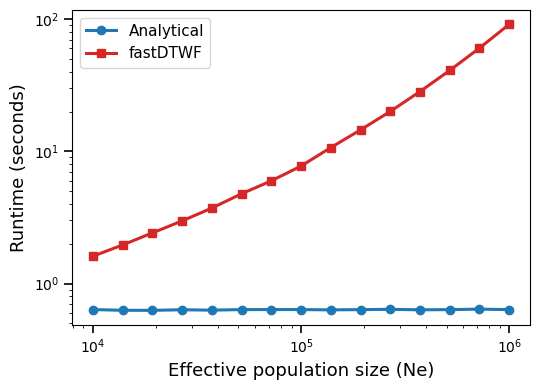

In [7]:
# Load results (or skip if df already exists)
df = pd.read_csv("time_sims.txt", sep="\t")

fig, ax = plt.subplots(figsize=(5.5, 4))

# Plot median runtimes
ax.plot(
    df["Ne"], df["Analytical_mean_s"],
    marker="o", lw=2.2, ms=6,
    color="#1f77b4", label="Analytical"
)

ax.plot(
    df["Ne"], df["fastDTWF_mean_s"],
    marker="s", lw=2.2, ms=6,
    color="#d62728", label="fastDTWF"
)

# Log–log scaling
ax.set_xscale("log")
ax.set_yscale("log")

# Labels
ax.set_xlabel("Effective population size (Ne)", fontsize=13)
ax.set_ylabel("Runtime (seconds)", fontsize=13)

# Styling
ax.legend(fontsize=11)
ax.tick_params(direction="out", length=6, width=1.2)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.savefig("../Figures/runtime_scaling.svg", dpi=300)
plt.show()
